In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
import os
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (
    save_pickle_file, 
    load_pickle_file,
    save_csv_file, 
    load_csv_file, 
    get_project_path
)

from flonacomldft.internal_coordinates import (
    Coordinates_mapping, 
    get_collective_variables_from_xs
)

In [15]:
def save_accs(adaptives, isomer_name, save_path):
    
    accs = {method: torch.cat( 
        adaptives[method]['accs']
        ).float().mean(dim=1) for method in adaptives.keys()}
    accs_df = pd.DataFrame(accs)

    save_csv_file(accs_df, 
                  'accs_ab-flowMC_{:s}.csv'.format(isomer_name), 
                  save_path)
    
    print('{:s} accs saved!'.format(isomer_name))

    return accs

In [16]:
def save_cvs_energy(adaptives_per_isomer, isomer_name, save_plot_data_path):
    
    cvs_energy_dfs = []

    for method in adaptives_per_isomer.keys():

        us = torch.cat( adaptives_per_isomer[method]['us'] )
        us = us.reshape(us.shape[0], 
                        us.shape[1],
                        1)
        cvs = adaptives_per_isomer[method]['cvs']

        print(cvs.shape, us.shape)

        cvs_energy = torch.cat( (cvs, us), 
                                dim=2 )

        cols = ['Method', 'C', 'R', 'U']

        cvs_energy_df = pd.DataFrame(columns=cols)
        cvs_energy_df[cols[1:]] = cvs_energy.reshape(-1, 3).detach().numpy()
        cvs_energy_df[cols[0]] = method

        cvs_energy_dfs.append(cvs_energy_df)

    cvs_energy_df = pd.concat(cvs_energy_dfs)

    save_csv_file(cvs_energy_df,
                'cvs_energy_ab-flowMC_{:s}.csv'.format(isomer_name),
                save_plot_data_path)

    print('{:s} cvs_energy saved!'.format(isomer_name))
                    
    return cvs_energy

# DATA FIGURE 1

In [17]:
# 350K results
torch.manual_seed(42)
project_path = get_project_path()
save_plot_data_path = "data_for_plots"

In [18]:
idx = [2994169, 3001962]

adaptives_path = [ ['1-adaptive/results_adaptive_is0_29941690/adaptive_sampling_is0_'+str(idx[0])+'0.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_30019620/adaptive_sampling_is0_'+str(idx[1])+'0.pkl'
                     ],
                   ['1-adaptive/results_adaptive_is1_29941694/adaptive_sampling_is1_'+str(idx[0])+'4.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_30019624/adaptive_sampling_is1_'+str(idx[1])+'4.pkl'
                    ] 
                ]

#cvs_path = ['1-adaptive/results_adaptive_is0_29941690/cvs_is0_29941690.pkl',                     
#            '1-adaptive/results_adaptive_is1_29941694/cvs_is1_29941694.pkl'                   
#          ]

methods_name = ['ab-flowMC w.o. MLP', 'ab-flowMC']

In [19]:
#adaptives = {i: load_pickle_file(adaptive_path, project_path) for i, adaptive_path in enumerate([adaptives_path[0][0], adaptives_path[1][0]])}

In [20]:
#cvs = {i: load_pickle_file(cvs_path[i], project_path) for i in range(len(cvs_path))}
#cvs[0].shape, cvs[1].shape

In [21]:
#for key in adaptives.keys():
#    xs = torch.cat(adaptives[key]['xs'])
#    isomers = torch.cat(adaptives[key]['isomers'])
#
#    cvs = get_collective_variables_from_xs(xs, isomers)
#
#    save_pickle_file(cvs, cvs_path[key], project_path)


In [22]:
adaptives = {}

for i, adaptives_per_isomer_paths in enumerate(adaptives_path):
    
    adaptives_per_isomer = {}
    
    for method_name, adaptive_path in zip(methods_name, adaptives_per_isomer_paths):
        
        adaptive = load_pickle_file(adaptive_path, project_path)
        adaptives_per_isomer[method_name] = adaptive

        isomer_name, number_id = adaptive_path.split('/')[-2].split('_')[-2:]
        cvs_file_path = '/'.join( adaptive_path.split('/')[:2] + ['cvs_{:s}_{:s}.pkl'.format(isomer_name, number_id)] )

        cvs = load_pickle_file(cvs_file_path, project_path)

        adaptives_per_isomer[method_name]['cvs'] = cvs
    
    adaptives[i] = adaptives_per_isomer

In [23]:
time_mcmc_df = []

for isomer in [0, 1]:
    for key in adaptives[isomer].keys():
        df = pd.DataFrame(columns=['Method', 'Time', 'Isomer'])
        
        if 'MLP' not in key:
            time_flatten = [t for time_list in adaptives[isomer][key]['time_mcmc'] for t in time_list]
        else:
            time_flatten = adaptives[isomer][key]['time_mcmc']
        print(key, len(time_flatten), isomer)
        t_min = min(time_flatten)
        time_mcmc = [t-t_min for t in time_flatten]

        df['Time'] = time_mcmc
        df['Method'] = key
        df['Isomer'] = isomer

        df['Time'] = df['Time']/3600

        time_mcmc_df.append(df)

time_mcmc_df = pd.concat(time_mcmc_df)
time_mcmc_df.to_csv(project_path + '/' + save_plot_data_path + '/time_mcmc_ab-flowMC.csv')
print('time mcmc saved!')

ab-flowMC w.o. MLP 600 0
ab-flowMC 600 0
ab-flowMC w.o. MLP 600 1
ab-flowMC 600 1
time mcmc saved!


In [24]:
accs_is0 = save_accs(adaptives[0], 'is0', project_path + '/' + save_plot_data_path)
accs_is1 = save_accs(adaptives[1], 'is1', project_path + '/' + save_plot_data_path)

is0 accs saved!
is1 accs saved!


In [25]:
cvs_energy_is0 = save_cvs_energy(adaptives[0], 'is0', project_path + '/' + save_plot_data_path)
cvs_energy_is1 = save_cvs_energy(adaptives[1], 'is1', project_path + '/' + save_plot_data_path)

torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])


is0 cvs_energy saved!
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
is1 cvs_energy saved!


In [26]:
for isomer_label in adaptives:

    mlp_model = adaptives[0][methods_name[1]]['dict_mlps'][-1][0]['model']
    datasets = adaptives[0][methods_name[1]]['mlps_datasets'][0]
    true_values = {dataset_label: datasets[dataset_label][0][:, 12].flatten() for dataset_label in datasets.keys()}
    predict_values = {dataset_label: mlp_model(datasets[dataset_label][0][:, :12]).flatten() for dataset_label in datasets.keys()}

    mlp_dfs = []

    for dataset_label in datasets.keys():
        mlp_df = pd.DataFrame(columns=['Dataset label', 'True values', 'Predict values'])
        mlp_df['True values'] = true_values[dataset_label].detach().numpy()
        mlp_df['Predict values'] = predict_values[dataset_label].detach().numpy()
        mlp_df['Dataset label'] = dataset_label
        mlp_dfs.append(mlp_df)

    mlp_dfs = pd.concat(mlp_dfs, ignore_index=True)

    save_csv_file(mlp_dfs,
                'mlps_datasets_ab-flowMC_is{:d}.csv'.format(isomer_label),
                project_path + '/' + save_plot_data_path)

    print('is{:d} mlp_datasets saved!'.format(isomer_label))                      

is0 mlp_datasets saved!
is1 mlp_datasets saved!


# DATA FIGURE 2

In [27]:
idx_path = idx = [3092241, 3092244]# [3054029, 3054425]#[3074955, 3075074]
mcmcs_path = ['4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'1/checkpoint_NA_2750.pkl',
            '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'1/mixture_mcmc_dic_'+str(idx_path[1])+'1.pkl'
            ]

cvs_path = ['cvs_temporal/cvs_slices_'+str(idx_path[0])+'1_2750.pkl',
            '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'1/cvs_mixture_'+str(idx_path[1])+'1.pkl'
            ]

mcmcs_name = ['ab-flowMM w.o. MLP', 'ab-flowMM']

In [28]:
mcmcs = {}

for i in range(len(mcmcs_path)):
    
    mcmc = load_pickle_file(mcmcs_path[i], project_path)
    cvs = load_pickle_file(cvs_path[i], project_path)

    mcmc['cvs'] = cvs
    
    mcmcs[mcmcs_name[i]] = mcmc

In [29]:
n=2750

cvs_energy_is_dfs = []

for method in mcmcs.keys():

    us = mcmcs[method]['us'][:n]
    isomers = mcmcs[method]['isomers'][:n]

    us = us.reshape(us.shape[0], 
                    us.shape[1],
                    1)
    isomers = isomers.reshape(isomers.shape[0],
                                isomers.shape[1],
                                1)
    cvs = mcmcs[method]['cvs'][:n]

    cvs_energy_is_ = torch.cat( (cvs, us, isomers), 
                            dim=2 )

    cols = ['Method', 'C', 'R', 'U', 'Isomer']

    cvs_energy_is_df = pd.DataFrame(columns=cols)
    cvs_energy_is_df[cols[1:]] = cvs_energy_is_.reshape(-1, 4).detach().numpy()
    cvs_energy_is_df[cols[0]] = method

    cvs_energy_is_dfs.append(cvs_energy_is_df)

cvs_energy_is = pd.concat(cvs_energy_is_dfs, ignore_index=True)

In [30]:
cvs_energy_is.to_csv(
    project_path + '/' + save_plot_data_path + '/cvs_energy_is_ab-flowMM.csv', 
    index=False)

In [31]:
isomers_dfs = []

for method in mcmcs.keys():

    isomers = mcmcs[method]['isomers'][:n]
    chains = [str(i) for i in range(isomers.shape[1])]
    isomers_df = pd.DataFrame(columns=['Method']+chains)
    isomers_df[chains] = isomers.detach().numpy()
    isomers_df['Method'] = method

    isomers_dfs.append(isomers_df)

isomers_df = pd.concat(isomers_dfs, ignore_index=True)

In [32]:
time_mcmcs = {}

for mcmc_name in mcmcs.keys():

    time_vals = mcmcs[mcmc_name]['time_mcmc'][:n]
    time_min = min(time_vals)
    time_abs = [(time - time_min)/3600 for time in time_vals]

    time_mcmcs[mcmc_name] = time_abs

time_mcmcs_df = pd.DataFrame(time_mcmcs)

In [33]:
time_mcmcs_df.to_csv(
    project_path + '/' + save_plot_data_path + '/time_mcmcs_ab-flowMM.csv', 
    index=False)

In [34]:
isomers_df.to_csv(
    project_path + '/' + save_plot_data_path + '/isomers_ab-flowMM.csv', 
    index=False)

In [35]:
from flonacomldft.models.mixture import Mixture

In [36]:
mixture_models = {}

for method_adaptive, method_mcmc in zip(methods_name, mcmcs_name):
    
    models = []

    for isomer_label in adaptives.keys():

        model = adaptives[isomer_label][method_adaptive]['dict_flows'][15][0]['model']
        models.append(model)

    mixture = Mixture(models, torch.tensor([0.75, 0.25]))

    mixture_models[method_mcmc] = mixture

In [37]:
N = 3500

density_samples_dfs = []

for method_mcmc in mcmcs_name:

    samples, isomers = mixture_models[method_mcmc].sample(N, return_mus=True)
    isomers = isomers.reshape(-1, 1)
    
    nll = mixture_models[method_mcmc].nll(samples).reshape(-1, 1)
    cvs = get_collective_variables_from_xs(samples.reshape(N, 1, 12), 
                                        isomers)
    density_samples = torch.cat((cvs.squeeze(), nll, isomers), dim=1).detach().numpy()

    cols = ['Method', 'C', 'R', 'NLL', 'Isomer']

    density_samples_df = pd.DataFrame(columns=cols)
    density_samples_df[cols[1:]] = density_samples
    density_samples_df[cols[0]] = method_mcmc

    density_samples_dfs.append(density_samples_df)

density_samples_dfs = pd.concat(density_samples_dfs, ignore_index=True)

In [38]:
save_csv_file(density_samples_dfs,
            'density_samples_ab-flowMM.csv',
            project_path + '/' + save_plot_data_path,
            index=False)

print('density_samples mixtures saved!')

density_samples mixtures saved!


# Populations

In [39]:
mcmc_paths = ['5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'0/mixture_mcmc_dic_'+str(idx_path[1])+'0.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'1/mixture_mcmc_dic_'+str(idx_path[1])+'1.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'2/mixture_mcmc_dic_'+str(idx_path[1])+'2.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'3/mixture_mcmc_dic_'+str(idx_path[1])+'3.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'4/mixture_mcmc_dic_'+str(idx_path[1])+'4.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_'+str(idx_path[1])+'5/mixture_mcmc_dic_'+str(idx_path[1])+'5.pkl'
              ]

mcmc_paths_dft = [
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'0/checkpoint_NA_2750.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'1/checkpoint_NA_2750.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'2/checkpoint_NA_2750.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'3/checkpoint_NA_2750.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'4/checkpoint_NA_2750.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_'+str(idx_path[0])+'5/checkpoint_NA_2750.pkl'
              ]

keys = [ 'ab-flowMM slice {:d} MD {:d}'.format(i, j) for j in [500, 
                                                               4000
                                                               ] for i in [5, 15, 30]] + [
        'ab-flowMM w.o. MLP slice {:d} MD {:d}'.format(i, j) for j in [500, 
                                                                      4000
                                                                      ] for i in [5, 15, 30]]
mcmcs = [load_pickle_file(mcmc_path, project_path) for mcmc_path in mcmc_paths+mcmc_paths_dft]

In [40]:
isomers = {key: mcmc['isomers'][:2750] for key, mcmc in zip(keys, mcmcs)}

In [41]:
populations_df = pd.DataFrame()

for key in keys:
    isomers_selection = isomers[key][250:2000, :].detach().numpy()
    means = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).mean(axis=1)
    stds = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).std(axis=1)
    populations_df[key] = means

populations_df.to_csv(
    project_path + '/' + save_plot_data_path + '/populations_ab-flowMM.csv', 
    index=False)

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

(0.0, 0.02)

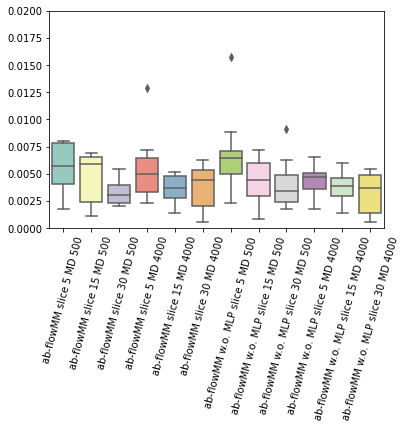

In [43]:
sns.boxplot(data=populations_df, palette="Set3")
plt.xticks(rotation=75)
plt.ylim(0, 0.02)

## Suplementary data

### Acceptance rate

In [44]:
accs = {key: mcmc['accs'][:2750].float().mean(dim=1) for key, mcmc in zip(keys, mcmcs)}
acceptances_df = pd.DataFrame(accs)

acceptances_df.to_csv(
    project_path + '/' + save_plot_data_path + '/acceptances_ab-flowMM.csv', 
    index=False)


### NLL

In [45]:
adaptives.keys()

dict_keys([0, 1])

In [46]:
nlls_df = []

for isomer in adaptives.keys():

    for method in adaptives[isomer].keys():

        df = pd.DataFrame(columns=['Method', 'ISOMER', 'NLLS', 'US', 'STEPS'])

        nlls = torch.stack(adaptives[isomer][method]['nlls']).flatten().detach().numpy()
        us = torch.stack(adaptives[isomer][method]['us_proposals'])[:, 1:].flatten().detach().numpy()
        print(method)
        df['NLLS'] = nlls
        df['US'] = us
        df['Method'] = method
        df['ISOMER'] = isomer
        df['STEPS'] = np.arange(len(nlls))

        nlls_df.append(df)

nlls_df = pd.concat(nlls_df)

nlls_df.to_csv(
    project_path + '/' + save_plot_data_path + '/nll_ab-flowMC.csv', 
    index=False)

ab-flowMC w.o. MLP
ab-flowMC
ab-flowMC w.o. MLP
ab-flowMC


### Flow losses

In [47]:
flow_losses_df = []

for isomer in adaptives.keys():

    for method in adaptives[isomer].keys():

        df = pd.DataFrame(columns=['Method', 'ISOMER', 'FLOW_LOSSES', 'STEPS'])

        flow_losses = torch.tensor([adaptives[isomer][method]['dict_flows'][i][0]['losses'] for i in range(len(adaptives[isomer][method]['dict_flows']))]).flatten().detach().numpy()

        df['FLOW_LOSSES'] = flow_losses
        df['Method'] = method
        df['ISOMER'] = isomer
        df['STEPS'] = np.arange(len(flow_losses))

        flow_losses_df.append(df)

flow_losses_df = pd.concat(flow_losses_df)

flow_losses_df.to_csv(
    project_path + '/' + save_plot_data_path + '/flow_losses_ab-flowMC.csv', 
    index=False)

### MLP losses

In [48]:
mlp_train_losses_df = []
mlp_test_losses_df = []

for isomer in adaptives.keys():

    for method in adaptives[isomer].keys():

        if 'w.o. MLP' in method:
            continue
        else:

            df_train = pd.DataFrame(columns=['Method', 'ISOMER', 'TRAIN_LOSSES'])
            df_test = pd.DataFrame(columns=['Method', 'ISOMER', 'TEST_LOSSES'])

            train_losses = [adaptives[isomer][method]['dict_mlps'][i][0]['train_losses'] for i in range(len(adaptives[isomer][method]['dict_mlps']))]#.flatten().numpy()
            test_losses = [adaptives[isomer][method]['dict_mlps'][i][0]['test_losses'] for i in range(len(adaptives[isomer][method]['dict_mlps']))]#).flatten().numpy()

            train_losses = [loss for losses in train_losses for loss in losses]
            test_losses = [loss for losses in test_losses for loss in losses]

            df_train['TRAIN_LOSSES'] = train_losses
            df_test['TEST_LOSSES'] = test_losses

            for df in [df_train, df_test]:
                df['Method'] = method
                df['ISOMER'] = isomer

            mlp_train_losses_df.append(df_train)
            mlp_test_losses_df.append(df_test)

mlp_train_losses_df = pd.concat(mlp_train_losses_df)
mlp_test_losses_df = pd.concat(mlp_test_losses_df)

mlp_train_losses_df.to_csv(
    project_path + '/' + save_plot_data_path + '/mlp_train_losses_ab-flowMC.csv', 
    index=False)

mlp_test_losses_df.to_csv(
    project_path + '/' + save_plot_data_path + '/mlp_test_losses_ab-flowMC.csv', 
    index=False)

In [49]:
flow_losses_df

,Method,ISOMER,FLOW_LOSSES,STEPS
0,ab-flowMC w.o. MLP,0,-10.773739,0
1,ab-flowMC w.o. MLP,0,-10.781300,1
2,ab-flowMC w.o. MLP,0,-10.788826,2
3,ab-flowMC w.o. MLP,0,-10.796333,3
4,ab-flowMC w.o. MLP,0,-10.803827,4
...,...,...,...,...
6195,ab-flowMC,1,-12.321617,6195
6196,ab-flowMC,1,-12.323711,6196
6197,ab-flowMC,1,-12.325800,6197
6198,ab-flowMC,1,-12.327878,6198
